In [ ]:
# cnn project
from google.colab import drive
drive.mount("/content/drive")
train_path = "/content/drive/MyDrive/Colab_Notebooks/dataset/train"
test_path = "/content/drive/MyDrive/Colab_Notebooks/dataset/test"

from tensorflow.keras.preprocessing.image import ImageDataGenerator

# load dataset
train_data = ImageDataGenerator(rescale=1./255)
test_data = ImageDataGenerator(rescale=1./255)

train = train_data.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test = test_data.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

print("train data index")
print(train.class_indices)

print("test data index")
print(test.class_indices)

# model
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense
from tensorflow.keras.preprocessing import image

# model

model = Sequential()

# first convolution layer
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(150,150,3)
))

# first pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# second convolution layer
model.add(Conv2D(
    filters=64,
    kernel_size=(3,3),
    activation='relu'
))

# second pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# third convolution layer
model.add(Conv2D(
    filters=128,
    kernel_size=(3,3),
    activation='relu'
))

# third pooling layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model.add(Flatten())

# hidden layer
model.add(Dense(units=128,activation='relu'))

#output layer
model.add(Dense(units=1,activation='sigmoid'))


# model summary
model.summary()

# compile model
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

# train model
history = model.fit(train,validation_data=test,epochs=10)

# save model
model.save("dog_cat_classifier.keras")

Mounted at /content/drive
Found 402 images belonging to 2 classes.
Found 2 images belonging to 2 classes.
train data index
{'cats': 0, 'dogs': 1}
test data index
{'cats': 0, 'dogs': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 76s 6s/step - accuracy: 0.5025 - loss: 0.7951 - val_accuracy: 0.5000 - val_loss: 0.6962
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5025 - loss: 0.6926 - val_accuracy: 0.5000 - val_loss: 0.7057
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5249 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6834
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.7040 - loss: 0.6396 - val_accuracy: 0.5000 - val_loss: 0.7331
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.6965 - loss: 0.5688 - val_accuracy: 0.5000 - val_loss: 0.6535
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.7388 - loss: 0.5106 - val_accuracy: 1.0000 - val_loss: 0.4728
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.8209 - loss: 0.4038 - val_accuracy: 1.0000 - val_loss: 0.4126
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.8831 - loss: 0.3091 - val_accuracy: 1.0000 - val_loss:

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model("dog_cat_classifier.keras")

img = image.load_img("images1.jpeg",target_size=(150,150))

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(img_array,axis=0)

# prediction
pred = model.predict(img_array)
# print(pred)

if pred[0][0] > 0.5:
  print("Dog")
else:
  print("cat")


FileNotFoundError: [Errno 2] No such file or directory: 'images1.jpeg'

Training Images Shape: (60000, 28, 28)
Training Labels Shape: (60000,)
Testing Images Shape: (10000, 28, 28)
Testing Labels Shape: (10000,)


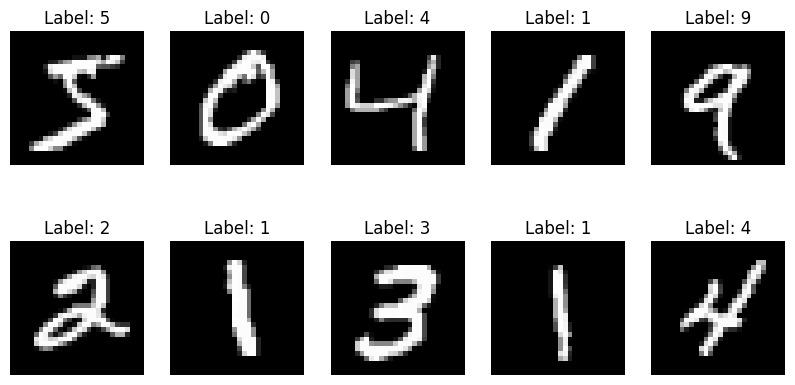

(60000, 28, 28, 1)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 46s 30ms/step - accuracy: 0.9273 - loss: 0.2366 - val_accuracy: 0.9793 - val_loss: 0.0687
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9740 - loss: 0.0884 - val_accuracy: 0.9860 - val_loss: 0.0473
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9814 - loss: 0.0627 - val_accuracy: 0.9883 - val_loss: 0.0412
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9837 - loss: 0.0512 - val_accuracy: 0.9898 - val_loss: 0.0378
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9864 - loss: 0.0446 - val_accuracy: 0.9912 - val_loss: 0.0354
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9890 - loss: 0.0351 - val_accuracy: 0.9914 - val_loss: 0.0350
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9898 - loss: 0.0334 - val_accuracy: 0.9926 - val_loss: 0.0336
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.9914 -

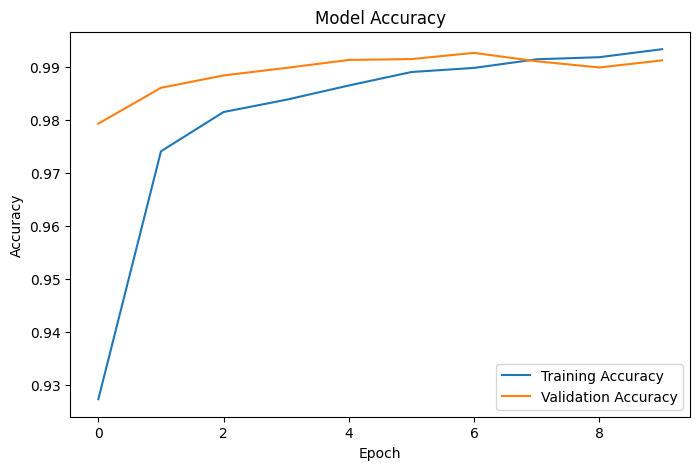

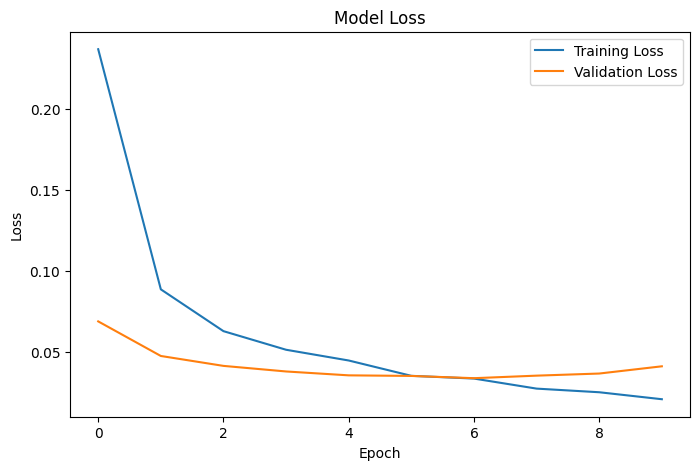

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted Digit: 7
Actual Digit: 7


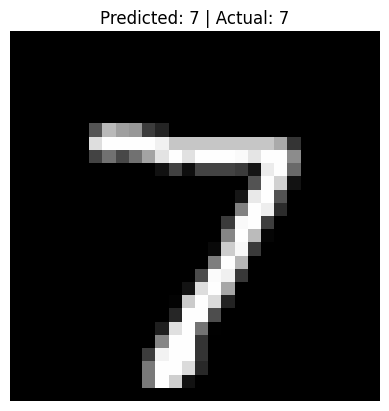

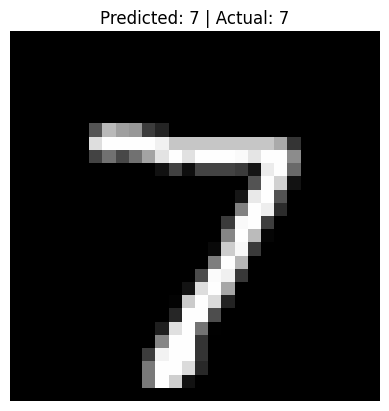

In [2]:
# example
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# load data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("Testing Images Shape:", X_test.shape)
print("Testing Labels Shape:", y_test.shape)

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.show()

X_train = X_train / 255.0
X_test = X_test / 255.0

X_train = X_train.reshape(60000,28,28,1)
X_test = X_test.reshape(10000,28,28,1)

print(X_train.shape)


model = Sequential()

# First Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolution Layer
model.add(Conv2D(64, (3,3), activation='relu'))

# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Hidden Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

prediction = model.predict(X_test[:1])

predicted_class = np.argmax(prediction)

print("Predicted Digit:", predicted_class)
print("Actual Digit:", y_test[0])

plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted: {predicted_class} | Actual: {y_test[0]}")

plt.axis("off")

plt.show()

plt.imshow(X_test[0].reshape(28,28), cmap='gray')

plt.title(f"Predicted: {predicted_class} | Actual: {y_test[0]}")

plt.axis("off")

plt.show()


model.save("mnist_cnn.keras")

from tensorflow.keras.models import load_model

loaded_model = load_model("mnist_cnn.keras")